# Задание.

1. Реализуйте функцию, которая проверяет гипотезу о равенстве средних для ratio-метрик с помощью дельта-метода.
2. Проверьте на данных с семинара, что распределение p-value на АА тестрах равномерно, и мощность совпадает с мощностями линеаризации и бутстрепа.

In [1]:
from typing import List, Tuple, Dict
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt
from tqdm import tqdm

In [2]:
def check_delta_method(
    a: List[List[float]],
    b: List[List[float]],
) -> Tuple[float, float]:
    """Проверка гипотезы о равенстве средних метрики отношения с помощью дельта-метода.

    a: List[List], список списков длин сессий пользователей контрольной группы
    b: List[List], список списков длин сессий пользователей пилотной группы

    return: (pvalue, pe) - pvalue и точечная оценка разности средних (b-a).
    """

    x_a = np.array([np.sum(i) for i in a])
    x_b = np.array([np.sum(i) for i in b])

    y_a = np.array([len(i) for i in a])
    y_b = np.array([len(i) for i in b])

    mu_x_a = np.mean(x_a)
    mu_x_b = np.mean(x_b)
    mu_y_a = np.mean(y_a)
    mu_y_b = np.mean(y_b)

    var_a = (
        1 / (mu_y_a**2) * np.var(x_a)
        - 2 * mu_x_a / (mu_y_a**3) * np.cov(x_a, y_a)[0, 1]
        + (mu_x_a**2) / (mu_y_a**4) * np.var(y_a)
    )
    var_b = (
        1 / (mu_y_b**2) * np.var(x_b)
        - 2 * mu_x_b / (mu_y_b**3) * np.cov(x_b, y_b)[0, 1]
        + (mu_x_b**2) / (mu_y_b**4) * np.var(y_b)
    )

    pe = np.sum(x_b) / np.sum(y_b) - np.sum(x_a) / np.sum(y_a)
    t = pe / np.sqrt(var_a / len(x_a) + var_b / len(x_b))

    dof = len(x_a) + len(x_b) - 2
    pvalue = 2 * (1 - stats.t.cdf(np.abs(t), dof))
    return pvalue, pe


def plot_pvalue_distribution_power(
    dict_pvalues: Dict[str, np.ndarray], alpha: float = 0.05
):
    """Рисует графики распределения pvalue."""
    X = np.linspace(0, 1, 1000)
    for key, pvalues in dict_pvalues.items():
        Y = np.searchsorted(np.sort(pvalues), X) / len(pvalues)
        prob_p = np.mean(np.array(pvalues) < alpha)
        plt.plot(X, Y, label=f"{key}, prob_p={prob_p:0.2f}")
    plt.plot([alpha, alpha], [0, 1], "--k", alpha=0.8)
    plt.plot([0, 1], [0, 1], "--k", alpha=0.8)
    plt.title("Оценка распределения p-value", size=16)
    plt.xlabel("p-value", size=12)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()

In [3]:
df = pd.read_csv("06-game_sessions.csv")
df["date"] = pd.to_datetime(df["date"])
df_pre_exp = df[df["date"] < datetime(2024, 5, 11)]
df_exp = df[df["date"] >= datetime(2024, 5, 11)]

100%|██████████| 1000/1000 [00:10<00:00, 94.45it/s]


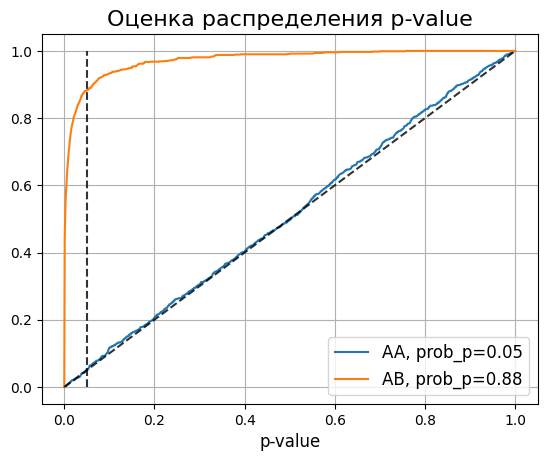

In [6]:
sample_size = 750
effect = 30

user_sessions = df_pre_exp.groupby("user_id")["value"].apply(list).values

len_ = len(user_sessions)
dict_pvalues = defaultdict(list)
for _ in tqdm(range(1000)):
    a, b = np.random.choice(user_sessions, (2, sample_size), False)
    pvalue_aa = check_delta_method(a, b)[0]
    dict_pvalues["AA"].append(pvalue_aa)
    b_effect = [list(np.array(row) + effect) for row in b]
    pvalue_ab = check_delta_method(a, b_effect)[0]
    dict_pvalues["AB"].append(pvalue_ab)

plot_pvalue_distribution_power(dict_pvalues)

In [7]:
user_sessions_a = df_exp[df_exp["group"] == 0].groupby("user_id")["value"].apply(list).values
user_sessions_b = df_exp[df_exp["group"] == 1].groupby("user_id")["value"].apply(list).values

pvalue, pe = check_delta_method(user_sessions_a, user_sessions_b)

print(f"Estimated diff: {pe.item()}")
print(f"Delta method p-value: {pvalue.item()}")

Estimated diff: 13.513984962406028
Delta method p-value: 0.22969836683548528
